# Radar FMCW #


_Mini-projet Traitement du Signal 2025-26_

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

%matplotlib ipympl

## I. Principe du radar FMCW ##


Pour prouver qu'on peut considérer la distance r(t) comme constante durant l'émission des signaux, il faut montrer que le déplacement maximal de la cible sur le temps de mesure est négligeable devant la résolution du radar. On obtient donc :
$\newline$
$$ \Delta r_{max}(T_{chirp}) = v_{max}.T_{chirp} = 4.69.10^{-4}~m$$
De même : 
$$ \Delta r_{max}(N_{chirp}T_{chirp}) = v_{max}.N_{chirp}T_{chirp} = 3 ~cm$$
$\newline$
Il faut donc maintenant trouver la résolution du radar. Comme on envoie un signal tous les $T_{chirp}$ on a donc $\Delta f_{min}=\frac{1}{T_{chirp}}$.
$\newline$ 
Or pour mesurer la distance r, le radar utilise une variation de fréquence (c'est le rôle joué par $\sigma(t)$). La variation de fréquence minimale est $\Delta f_{min}$ et elle est égale à : 
$$ pente~de~la~variation~de~fréquence ~.~ temps~de~voyage~du~signal = \frac{B}{T_{chirp}}.\frac{2\Delta r_{min}}{c}$$
D'où : $$\Delta r_{min} = \frac{c}{2B}$$
L'application numérique donne : $\Delta r_{min} = 1~m$
$\newline$ 
On a bien : $$\Delta r_{max}(T_{chirp})\ll\Delta r_{max}(N_{chirp}T_{chirp})\ll\Delta r_{min}$$
On peut donc considérer la distance comme constante durant la durée de la salve de chirp.

## II. Démodulation et bande de base ##
### A. Démodulation du signal reçu ###

Le signal reçu, conformément à l'énoncé est : $$x_{R}(t) = a(r(t))cos(\Phi_{R}(t))$$


Une fois le LNA passé : $$x_{R}(t) = k'a(r(t))cos(\Phi_{R}(t))$$


Dans le cas où on multiplie par un cosinus :  $$x_{R}(t) = k'a(r(t))cos(\Phi_{R}(t))cos(\Phi_{T}(t))$$


Les formules de trigonométrie nous donnent que :$$x_{R}(t) = k'a(r(t))\frac{1}{2}(cos(\Phi_{R}(t)-\Phi_{T}(t))+cos(\Phi_{T}(t)\Phi_{R}(t)))$$


De manière analogue dans le cas du sinus : $$x_{R}(t) = k'a(r(t))\frac{1}{2}(sin(\Phi_{R}(t)-\Phi_{T}(t))+sin(\Phi_{T}(t)+\Phi_{R}(t)))$$


On remarque que : $\Phi_{R}(t)+\Phi_{T}(t) \approx 2f_{c} = 154~GHz$ alors que $\Phi_{T}(t)-\Phi_{R}(t) \approx 1~Hz $ (en ordre de grandeur). Or la dernière étape est le bloc IF qui est un passe bas, le signal de fréquence $\Phi_{R}(t)+\Phi_{T}(t)$ est donc coupé alors que celui de fréquence $\Phi_{T}(t)-\Phi_{R}(t)$ passe sans problème. 


En posant $k = \frac{k'}{2}$ on trouve : $$x_{R}(t) = ka(r(t))(cos(\Phi_{T}(t)-\Phi_{R}(t)))$$
$$x_{R}(t) = ka(r(t))(sin(\Phi_{T}(t)-\Phi_{R}(t)))$$

Ainsi on doit choisir $f_{coupure}$ tel que $ \Phi_{T}(t)-\Phi_{R}(t)\ll f_{coupure}\ll \Phi_{R}(t)+\Phi_{T}(t)$, de sorte à être sur que le signal de haute fréquence soit supprimé mais que celui de basse fréquence passe tout le temps. Donc prendre $f_{coupure} = 20~GHz$ devrait faire l'affaire. 

### B. Démodulation en bande de base ###

On a en effectuant le rapport des signaux : $$ \frac{\tilde x_{R}(t)}{\tilde x_{T}(t)} = a(r(t)) e^{j(\Phi_{R}(t)-\Phi_{T}(t))}$$


On retrouve bien la différence $\Phi_{R}(t)-\Phi_{T}(t)$ souhaitée dans l'exponentielle complexe. Pour la suite il suffit de prendre la partie réelle pour le cosinus et la partie imaginaire pour le sinus puis les multiplier par $ k$.


En travaillant en bande de base, il est très facile de trouver la différence $\Phi_{R}(t)-\Phi_{T}(t)$ qui nous permettra par la suite de détreminer la vitesse de la cible (un rapport des signaux suffit) alors que le protocole de la partie II.A est long, moins évident à mettre en place et on risque potentiellement de perdre des données lors du filtrage. 

De manière absolue on perd de l'information car on filtre une partie du signal. Mais la partie filtrée ne comporte pas d'information utile à notre problème. Ce qui nous intéresse est la différence des phases $\Phi_{T}(t)-\Phi_{R}(t)$ et cette partie est bien laissée intacte. Donc du point de vue du traitement du signal aucune information n'est perdue. 


## III. Examen des signaux fournis ###



In [2]:
data = sio.loadmat('radar.mat')
xt = data['xt']
xr = data['xr']

Un chirp dure $T_{chirp}= \frac{22}{3} \mu s$. Or dans la taille de 'xt' est de 8800 points. Donc la fréquence d'échantillonage est :
$$ f_{ech} = \frac{8800}{T_{chirp}} = 1.2 ~GHz $$

/var/folders/_l/z5vqwjnn06l67wbqpt8pt73c0000gn/T/ipykernel_26651/4266127571.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


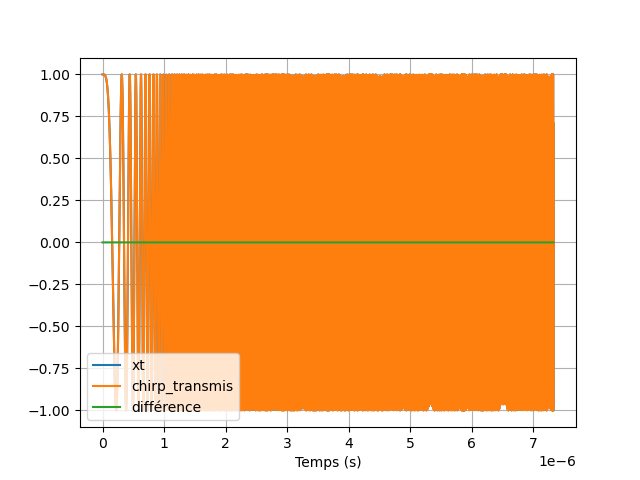

In [23]:
T_chirp= (22/3)*1e-6
N_chirp = 64
B = 150e6
beta = 2*np.pi*(B/T_chirp)
fc = 77e9
fech = 1.2e9


def sigma(t):
    return t%T_chirp

def phi_t(t):
    return 2*np.pi*fc*t + (beta/2)*sigma(t)**2

def chirp_transmis(t):
    return np.exp(1j*phi_t(t)-1j*2*np.pi*fc*t )

# Le code ci-dessus n'est pas le plus efficace, mais il est plus facile à comprendre et permet de montrer notre compréhension du problème.
# On aurait pu considérer la fonction ci dessous pour plus de simplicité :
# def chirp_transmis(t):
#    return np.exp(1j*(beta/2)*(t%T_chirp)**2)

time = np.linspace(0,T_chirp, len(xt), endpoint=False)
fig, ax = plt.subplots()
ax.plot(time, xt, label='xt')
ax.plot(time, chirp_transmis(time), label='chirp_transmis')
plt.plot(time, np.abs(xt.flatten() - chirp_transmis(time)), label='différence')
plt.xlabel("Temps (s)")
plt.grid(True)
plt.legend()    
plt.show()

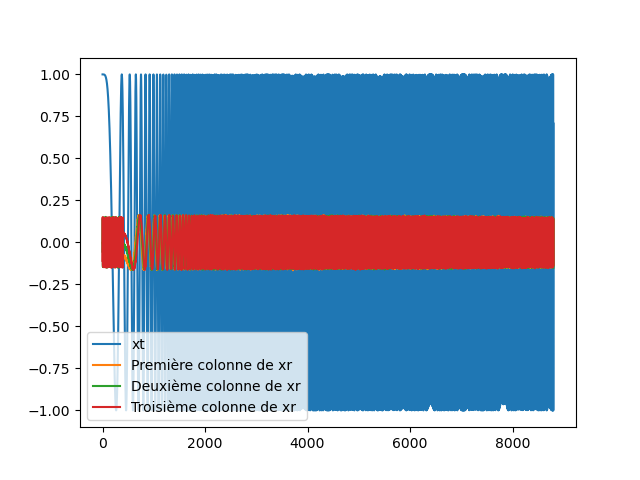

In [ ]:
fig, ax = plt.subplots()
ax.plot(xt, label='xt')
ax.plot(xr[:,0]*1000, label='Première colonne de xr')
ax.plot(xr[:,1]*1000, label='Deuxième colonne de xr')
ax.plot(xr[:,2]*1000, label='Troisième colonne de xr')
ax.legend()

On multplie par 1000 l'amplitudes 3 premières colones de xr pour mieux comparer leurs formes à celle de xt. On remarque en effet que xr a un retard de 400 points environ sur xt et que la forme est cependant bien identique pour $N\geq 398$. O note aussi que le dépahsage augmente avec l'indice de la colone de xr (la troisième colone de xr est plus retardé que la première).


Sur le graphique ci-dessous, nous avons supprimé le retard initial de 398 points pour aligner les signaux et mieux comparer leur forme et observer le déphasage. 

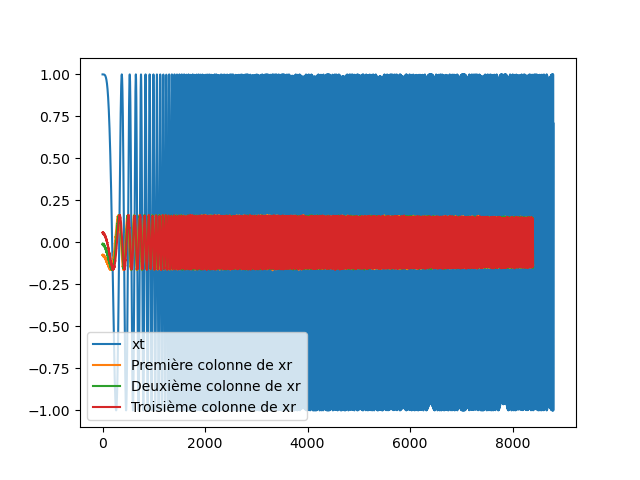

In [ ]:
fig, ax = plt.subplots()
ax.plot(xt, label='xt')
ax.plot(xr[398:,0]*1000, label='Première colonne de xr')
ax.plot(xr[398:,1]*1000, label='Deuxième colonne de xr')
ax.plot(xr[398:,2]*1000, label='Troisième colonne de xr')
ax.legend()

Comme mentionné ci-dessus le signal xr commence avec un retard de 398 points. Ce décalage correspond au temps que le signal met à parcourir l'aller retour entre la voiture et le radar. Or nous savons que la fréquence d'échantillonage est $f_{ech}= 1.2 ~GHz $ donc le retard $\Delta t$ vaut : 
$$ \Delta t = \frac{398}{f_{ech}} = 0.33 ~\mu s$$
Donc de manière analogue à la partie 1 : $$ c = \frac{2r(t)}{\Delta t}$$
D'où : $$r(t) = \frac{\Delta t. c}{2} = 49.75~m $$

Le résultat semble assez cohérent car selon l'énoncé la distance maximale d'une cible est de 200 m. Selon la question 1, la précision du radar est de l'odre du mètre, on peut donc arrondir le résulat à : $ r = 50~m$

## IV. Estimation de la distance r ###

## V. Estimation de la vitesse radiale $\overset{.}{r}$ ##

## VI. Pour aller plus loin ##